<a href="https://colab.research.google.com/github/Annyyzinha/projeto-final-processamento-imagens/blob/main/Projeto_Final_Processamento_Imagem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
import os

os.environ['KAGGLE_API_TOKEN'] = "KGAT_d1f481ff92de543fd6e288812b266bb0"

print("Baixando o dataset do Kaggle...")
!kaggle datasets download -d nodoubttome/skin-cancer9-classesisic

print("Descompactando os arquivos (isso pode levar alguns segundos)...")
!unzip -q skin-cancer9-classesisic.zip -d dataset_pele

print("Dataset baixado e descompactado com sucesso!")

Baixando o dataset do Kaggle...
Dataset URL: https://www.kaggle.com/datasets/nodoubttome/skin-cancer9-classesisic
License(s): other
100% 786M/786M [00:46<00:00, 17.9MB/s]

Descompactando os arquivos (isso pode levar alguns segundos)...
Dataset baixado e descompactado com sucesso!


In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

base_dir = '/content/dataset_pele/Skin cancer ISIC The International Skin Imaging Collaboration'
train_dir = os.path.join(base_dir, 'Train')
test_dir = os.path.join(base_dir, 'Test')

print("Preparando os geradores de imagens...")

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

print("\n--- Carregando imagens de TREINO ---")
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

print("\n--- Carregando imagens de TESTE ---")
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

nomes_das_classes = list(train_generator.class_indices.keys())
print(f"\nAs 9 doenças identificadas foram:\n{nomes_das_classes}")

Preparando os geradores de imagens...

--- Carregando imagens de TREINO ---
Found 2239 images belonging to 9 classes.

--- Carregando imagens de TESTE ---
Found 118 images belonging to 9 classes.

As 9 doenças identificadas foram:
['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']


In [5]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

print("A descarregar a arquitetura DenseNet121 base...")

base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)

predicoes = Dense(9, activation='softmax')(x)

modelo = Model(inputs=base_model.input, outputs=predicoes)

modelo.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("\nModelo construído e compilado com sucesso!")

A descarregar a arquitetura DenseNet121 base...
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

Modelo construído e compilado com sucesso!


In [6]:
print("Iniciando o treinamento da DenseNet121 para 9 classes...")

historico = modelo.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator,
    verbose=1
)

print("\nTreinamento concluído!")

Iniciando o treinamento da DenseNet121 para 9 classes...
Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.2479 - loss: 2.1196 - val_accuracy: 0.1610 - val_loss: 2.1561
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 48s 680ms/step - accuracy: 0.3332 - loss: 1.8304 - val_accuracy: 0.2712 - val_loss: 1.9993
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 47s 678ms/step - accuracy: 0.3698 - loss: 1.7146 - val_accuracy: 0.3305 - val_loss: 1.8696
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 47s 668ms/step - accuracy: 0.4011 - loss: 1.6274 - val_accuracy: 0.3305 - val_loss: 1.8941
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 48s 688ms/step - accuracy: 0.4368 - loss: 1.5629 - val_accuracy: 0.3644 - val_loss: 1.8049
Epoch 6/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 48s 695ms/step - accuracy: 0.4636 - loss: 1.5134 - val_accuracy: 0.3729 - val_loss: 1.8099
Epoch 7/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 49s 694ms/step - accuracy: 0.4636 - loss: 1.5081 - val_accuracy: 0.3814 - val_loss: 1.8671
Epoch 8/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 48s 

Gerando previsões no conjunto de teste (isso leva alguns segundos)...
4/4 ━━━━━━━━━━━━━━━━━━━━ 30s 6s/step

           RELATÓRIO DE CLASSIFICAÇÃO
                            precision    recall  f1-score   support

         actinic keratosis       1.00      0.06      0.12        16
      basal cell carcinoma       0.40      0.62      0.49        16
            dermatofibroma       0.50      0.12      0.20        16
                  melanoma       0.37      0.44      0.40        16
                     nevus       0.50      0.75      0.60        16
pigmented benign keratosis       0.25      0.62      0.36        16
      seborrheic keratosis       0.00      0.00      0.00         3
   squamous cell carcinoma       0.00      0.00      0.00        16
           vascular lesion       0.75      1.00      0.86         3

                  accuracy                           0.38       118
                 macro avg       0.42      0.40      0.34       118
              weighted avg       0.4

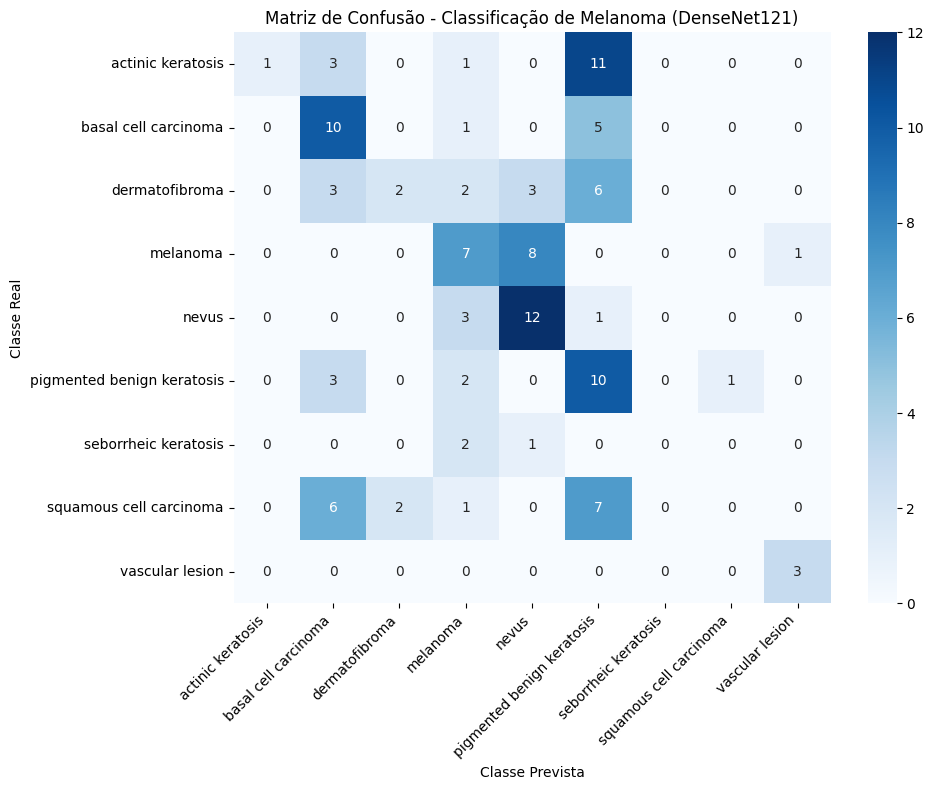

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

print("Gerando previsões no conjunto de teste (isso leva alguns segundos)...")
previsoes = modelo.predict(test_generator)
previsoes_classes = np.argmax(previsoes, axis=1)
rotulos_reais = test_generator.classes

print("\n" + "="*50)
print("           RELATÓRIO DE CLASSIFICAÇÃO")
print("="*50)
print(classification_report(rotulos_reais, previsoes_classes, target_names=nomes_das_classes, zero_division=0))

print("\n" + "="*50)
print("               MATRIZ DE CONFUSÃO")
print("="*50)
matriz = confusion_matrix(rotulos_reais, previsoes_classes)
plt.figure(figsize=(10,8))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=nomes_das_classes, yticklabels=nomes_das_classes)
plt.ylabel('Classe Real')
plt.xlabel('Classe Prevista')
plt.title('Matriz de Confusão - Classificação de Melanoma (DenseNet121)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()